<img src="https://s3-us-west-2.amazonaws.com/public.notion-static.com/7fa59d58-ba42-4de1-840a-e2e31ab9ce3b/ba416d9e-ee4d-4b7a-a9fe-a506333af2b7.png" alt="Abstract Banner" width="100%" height="200" style="object-fit: cover; border-radius: 8px;">
by: Elmar Leonard, Muhammad Rafi Andrianto and Valencia

# **Section 0: Project Initialization**

## **0.1 Importing Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [2]:
df = pd.read_csv('../Dataset/Cleaned Data/cleaned.csv')
df.shape

(111777, 39)

# **Section 1: Exploratory Data Analysis**

`cleaned.csv` is item-level (one row per order item). Several columns are actually order-level or customer-level facts that got repeated across every item row of an order during the original merge (payment info and review info both work this way verified directly below). Every order-level or customer-level column in this notebook is explicitly deduplicated by `order_id` before its distribution is examined.


In [3]:
df.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
order_item_id                    float64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english        str
seller_zip_code_prefix           float64
customer_unique_id                   str
customer_zip_code_prefix           int64
total_payment_value              float64
payment_installments             float64
payment_type    

In [4]:
# multi item sample on one order
multi = df.groupby('order_id').filter(lambda x: len(x) > 1)
example = multi['order_id'].iloc[0]
display(df[df['order_id']==example])

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,customer_unique_id,customer_zip_code_prefix,total_payment_value,payment_installments,payment_type,n_vouchers,voucher_value,review_score,review_comment_message,review_creation_date,review_answer_timestamp,seller_lat,seller_lng,seller_geo_city,seller_geo_state,customer_lat,customer_lng,customer_geo_city,customer_geo_state
10,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,1.0,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,2017-05-22 19:50:18,99.0,30.53,9000.0,42.0,12.0,39.0,garden_tools,29156.0,f2a85dec752b8517b5e58a06ff3cd937,20780,259.06,1.0,credit_card,0.0,0.0,1.0,Aguardando retorno da loja,2017-05-30 00:00:00,2017-05-30 23:13:47,-20.278513,-40.411675,cariacica,ES,-22.896463,-43.272172,rio de janeiro,RJ
11,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,2.0,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,2017-05-22 19:50:18,99.0,30.53,9000.0,42.0,12.0,39.0,garden_tools,29156.0,f2a85dec752b8517b5e58a06ff3cd937,20780,259.06,1.0,credit_card,0.0,0.0,1.0,Aguardando retorno da loja,2017-05-30 00:00:00,2017-05-30 23:13:47,-20.278513,-40.411675,cariacica,ES,-22.896463,-43.272172,rio de janeiro,RJ


`total_payment_value`, `payment_installments`, `payment_type`, `review_score`, and `customer_geo_city` are all identical across both rows of this order. `seller_geo_city` is also identical here, but only because this happens to be a single seller order. For the rare multi seller orders it would differ per item, so seller geography is treated at item-level throughout this notebook rather than deduplicated to order level.

Two tables are built: 
- **order-level** (everything that is genuinely one-per-order or one-per-customer)

- **item-level** (product dimensions, category, and seller geography, which can legitimately vary within a single order)


In [5]:
# fix data type
date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_customer_date', 'order_delivered_carrier_date',
             'order_estimated_delivery_date','shipping_limit_date','review_creation_date','review_answer_timestamp']
for c in date_cols:
    df[c] = pd.to_datetime(df[c])

df.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
order_item_id                           float64
product_id                                  str
seller_id                                   str
shipping_limit_date              datetime64[us]
price                                   float64
freight_value                           float64
product_weight_g                        float64
product_length_cm                       float64
product_height_cm                       float64
product_width_cm                        float64
product_category_name_english               str
seller_zip_code_prefix                  float64
customer_unique_id                      

In [6]:
# order_items aggregated to order-level
items_agg = df.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    n_items=('order_item_id', 'count'),
    n_distinct_sellers=('seller_id', 'nunique'),
    total_order_weight_g=('product_weight_g', 'sum'),
).reset_index()

items_agg['multi_seller_order'] = items_agg['n_distinct_sellers'] > 1
items_agg.head()


,order_id,total_price,total_freight,n_items,n_distinct_sellers,total_order_weight_g,multi_seller_order
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,1,650.0,False
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,1,30000.0,False
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,1,3050.0,False
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,1,200.0,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,1,3750.0,False


In [7]:
# date-derived features
date_feats = df.drop_duplicates('order_id')[[
    'order_id','order_purchase_timestamp','order_approved_at',
    'order_estimated_delivery_date','shipping_limit_date']].copy()

date_feats['approval_delay_hours'] = (date_feats['order_approved_at'] - date_feats['order_purchase_timestamp']).dt.total_seconds() / 3600
date_feats['promised_window_days'] = (date_feats['order_estimated_delivery_date'] - date_feats['order_approved_at']).dt.total_seconds() / 86400
date_feats['seller_dispatch_window_days'] = (date_feats['shipping_limit_date'] - date_feats['order_purchase_timestamp']).dt.total_seconds() / 86400
date_feats['purchase_month'] = date_feats['order_purchase_timestamp'].dt.to_period('M').astype(str)
date_feats['purchase_dow'] = date_feats['order_purchase_timestamp'].dt.day_name()
date_feats = date_feats.drop(columns=['order_purchase_timestamp','order_approved_at',
                                        'order_estimated_delivery_date','shipping_limit_date'])
date_feats.head()


,order_id,approval_delay_hours,promised_window_days,seller_dispatch_window_days,purchase_month,purchase_dow
0,e481f51cbdc54678b7cc49136f2d6af7,0.178333,15.536632,4.007431,2017-10,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,30.713889,17.858021,5.279745,2018-07,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,0.276111,26.628206,5.011505,2018-08,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,0.298056,26.176400,5.012419,2017-11,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,1.030556,12.069109,5.967338,2018-02,Tuesday


In [8]:
# dedupe first order-level facts that are repeated across item rows
order_level_facts = df.drop_duplicates('order_id')[[
    'order_id', 'order_status', 'customer_unique_id',
    'total_payment_value', 'payment_installments', 'payment_type', 'n_vouchers', 'voucher_value',
    'review_score', 'review_comment_message',
    'customer_geo_city', 'customer_geo_state', 'customer_lat', 'customer_lng']].copy()

order_level_facts['has_review_comment'] = order_level_facts['review_comment_message'].notna()
order_level_facts = order_level_facts.drop(columns=['review_comment_message'])
order_level_facts.head()


,order_id,order_status,customer_unique_id,total_payment_value,payment_installments,payment_type,n_vouchers,voucher_value,review_score,customer_geo_city,customer_geo_state,customer_lat,customer_lng,has_review_comment
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,7c396fd4830fd04220f754e42b4e5bff,38.71,1.0,credit_card,2.0,20.59,4.0,sao paulo,SP,-23.576983,-46.587161,True
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,af07308b275d755c9edb36a90c618231,141.46,1.0,boleto,0.0,0.00,4.0,barreiras,BA,-12.177924,-44.660711,True
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,3a653a41f6f9fc3d2a113cf8398680e8,179.12,3.0,credit_card,0.0,0.00,5.0,vianopolis,GO,-16.745150,-48.514783,False
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,7c142cf63193a1473d2e66489a9ae977,72.20,1.0,credit_card,0.0,0.00,5.0,sao goncalo do amarante,RN,-5.774190,-35.271143,True
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,72632f0f9dd73dfee390c9b22eb56dd6,28.62,1.0,credit_card,0.0,0.00,5.0,santo andre,SP,-23.676370,-46.514627,False


The step above isolates order-level attributes including payment details, customer geography, order status, and review ratings by deduplicating the dataset on order_id to eliminate additional row from multi-item orders. Additionally, the raw review text was transformed into a binary has_review_comment to track feedback participation without carrying unstructured text

In [9]:
# repeat customer behavior
customer_order_counts = order_level_facts.groupby('customer_unique_id')['order_id'].transform('nunique')
order_level_facts['customer_order_count'] = customer_order_counts
order_level_facts['is_repeat_customer'] = order_level_facts['customer_order_count'] > 1

print(f"One-time customers: {(~order_level_facts.drop_duplicates('customer_unique_id')['is_repeat_customer']).mean():.2%}")


One-time customers: 96.90%


In [10]:
# order-level analysis table
order_analysis_df = order_level_facts.merge(items_agg, on='order_id').merge(date_feats, on='order_id')
print("order_analysis_df shape:", order_analysis_df.shape)
order_analysis_df.head()

order_analysis_df shape: (98017, 27)


,order_id,order_status,customer_unique_id,total_payment_value,payment_installments,payment_type,n_vouchers,voucher_value,review_score,customer_geo_city,customer_geo_state,customer_lat,customer_lng,has_review_comment,customer_order_count,is_repeat_customer,total_price,total_freight,n_items,n_distinct_sellers,total_order_weight_g,multi_seller_order,approval_delay_hours,promised_window_days,seller_dispatch_window_days,purchase_month,purchase_dow
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,7c396fd4830fd04220f754e42b4e5bff,38.71,1.0,credit_card,2.0,20.59,4.0,sao paulo,SP,-23.576983,-46.587161,True,2,True,29.99,8.72,1,1,500.0,False,0.178333,15.536632,4.007431,2017-10,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,af07308b275d755c9edb36a90c618231,141.46,1.0,boleto,0.0,0.00,4.0,barreiras,BA,-12.177924,-44.660711,True,1,False,118.70,22.76,1,1,400.0,False,30.713889,17.858021,5.279745,2018-07,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,3a653a41f6f9fc3d2a113cf8398680e8,179.12,3.0,credit_card,0.0,0.00,5.0,vianopolis,GO,-16.745150,-48.514783,False,1,False,159.90,19.22,1,1,420.0,False,0.276111,26.628206,5.011505,2018-08,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,7c142cf63193a1473d2e66489a9ae977,72.20,1.0,credit_card,0.0,0.00,5.0,sao goncalo do amarante,RN,-5.774190,-35.271143,True,1,False,45.00,27.20,1,1,450.0,False,0.298056,26.176400,5.012419,2017-11,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,72632f0f9dd73dfee390c9b22eb56dd6,28.62,1.0,credit_card,0.0,0.00,5.0,santo andre,SP,-23.676370,-46.514627,False,1,False,19.90,8.72,1,1,250.0,False,1.030556,12.069109,5.967338,2018-02,Tuesday


In [11]:
# item-level analysis table (product dimensions, category, seller geography)
item_analysis_df = df[['order_id', 'order_item_id', 'product_weight_g', 'product_length_cm', 'product_height_cm',
                        'product_width_cm', 'product_category_name_english',
                        'seller_geo_city', 'seller_geo_state', 'seller_lat', 'seller_lng']].copy()
print("item_analysis_df shape:", item_analysis_df.shape)
item_analysis_df.head()


item_analysis_df shape: (111777, 11)


,order_id,order_item_id,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_geo_city,seller_geo_state,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,500.0,19.0,8.0,13.0,housewares,maua,SP,-23.680729,-46.444238
1,53cdb2fc8bc7dce0b6741e2150273451,1.0,400.0,19.0,13.0,19.0,perfumery,belo horizonte,MG,-19.807681,-43.980427
2,47770eb9100c2d0c44946d9cf07ec65d,1.0,420.0,24.0,19.0,21.0,auto,guariba,SP,-21.363502,-48.229601
3,949d5b44dbf5de918fe9c16f97b45f8a,1.0,450.0,30.0,10.0,20.0,pet_shop,belo horizonte,MG,-19.837682,-43.924053
4,ad21c59c0840e6cb83a9ceb5573f8159,1.0,250.0,51.0,15.0,15.0,stationery,mogi das cruzes,SP,-23.543395,-46.262086


| Feature | Derived from | Notes |
| --- | --- | --- |
| `purchase_month`, `purchase_dow` | order_purchase_timestamp | Extracted monthly cohorts (YYYY-MM) and day-of-week strings to capture macro seasonality and weekly purchasing trends. |
| `approval_delay_hours` | order_approved_at - order_purchase_timestamp | Payment processing latency in fractional hours; captures transaction authorization and payment clearance bottlenecks. |
| `promised_window_days` | order_estimated_delivery_date - order_approved_at | Promised delivery lead time in days presented to the customer upon payment approval. |
| `seller_dispatch_window_days` | shipping_limit_date - order_purchase_timestamp | Contractual lead-time buffer in days allocated for sellers to package and hand off goods to logistics carriers. |
| `n_items`, `total_price`, `total_freight` | order_items, aggregated to order-level | Aggregates item count, baseline item prices, and freight fees to reflect total item and shipping costs per order. |
| `n_distinct_sellers`, `multi_seller_order` | order_items.seller_id, aggregated | Counts unique merchants per order and flags split-fulfillment transactions (>1 seller). |
| `total_order_weight_g` | product_weight_g, summed per order | Total physical shipment weight in grams. serves as a physical driver for freight pricing and carrier handling timelines. |
| `total_payment_value`, `payment_installments`, `payment_type`, `n_vouchers`, `voucher_value` | payments, order-level | Financial settlement facts deduplicated on `order_id` to avoid artificial payment inflation across multi-item rows. |
| `has_review_comment` | review_comment_message, presence only | Binary indicator (True/False) capturing qualitative feedback participation without introducing unstructured text processing overhead. |
| `customer_order_count`, `is_repeat_customer` | customer_unique_id, counted across the dataset | Counts cumulative transactions per unique buyer across the dataset to isolate repeat behavior from one-time orders. |

## **1.1 Univariate Analysis**

### **1.1.1 `order_status`**

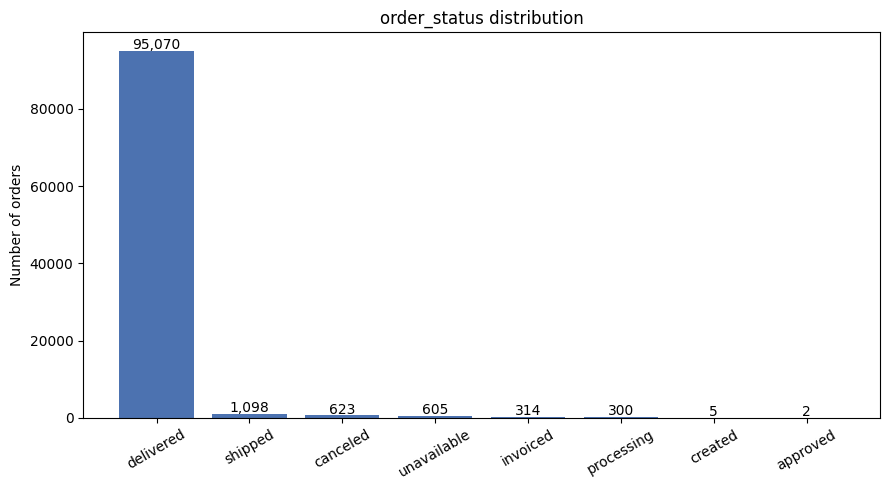

order_status
delivered      95070
shipped         1098
canceled         623
unavailable      605
invoiced         314
processing       300
created            5
approved           2
Name: count, dtype: int64

order_status
delivered      96.99
shipped         1.12
canceled        0.64
unavailable     0.62
invoiced        0.32
processing      0.31
created         0.01
approved        0.00
Name: count, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(9,5))
status_counts = order_analysis_df['order_status'].value_counts()
ax.bar(status_counts.index, status_counts.values, color='#4C72B0')
ax.set_title('order_status distribution')
ax.set_ylabel('Number of orders')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(status_counts.values):
    ax.text(i, v+500, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

print(status_counts)
print()
print((status_counts / status_counts.sum() * 100).round(2))


`delivered` dominates as expected, given the cleaning steps already removed the handful of orders with missing delivery dates under this status. The remaining statuses (`shipped`, `canceled`, `unavailable`, `invoiced`, `processing`) each make up a small fraction 


### **1.1.2 Order composition: `n_items`, `multi_seller_order`, `total_price`, `total_freight`**

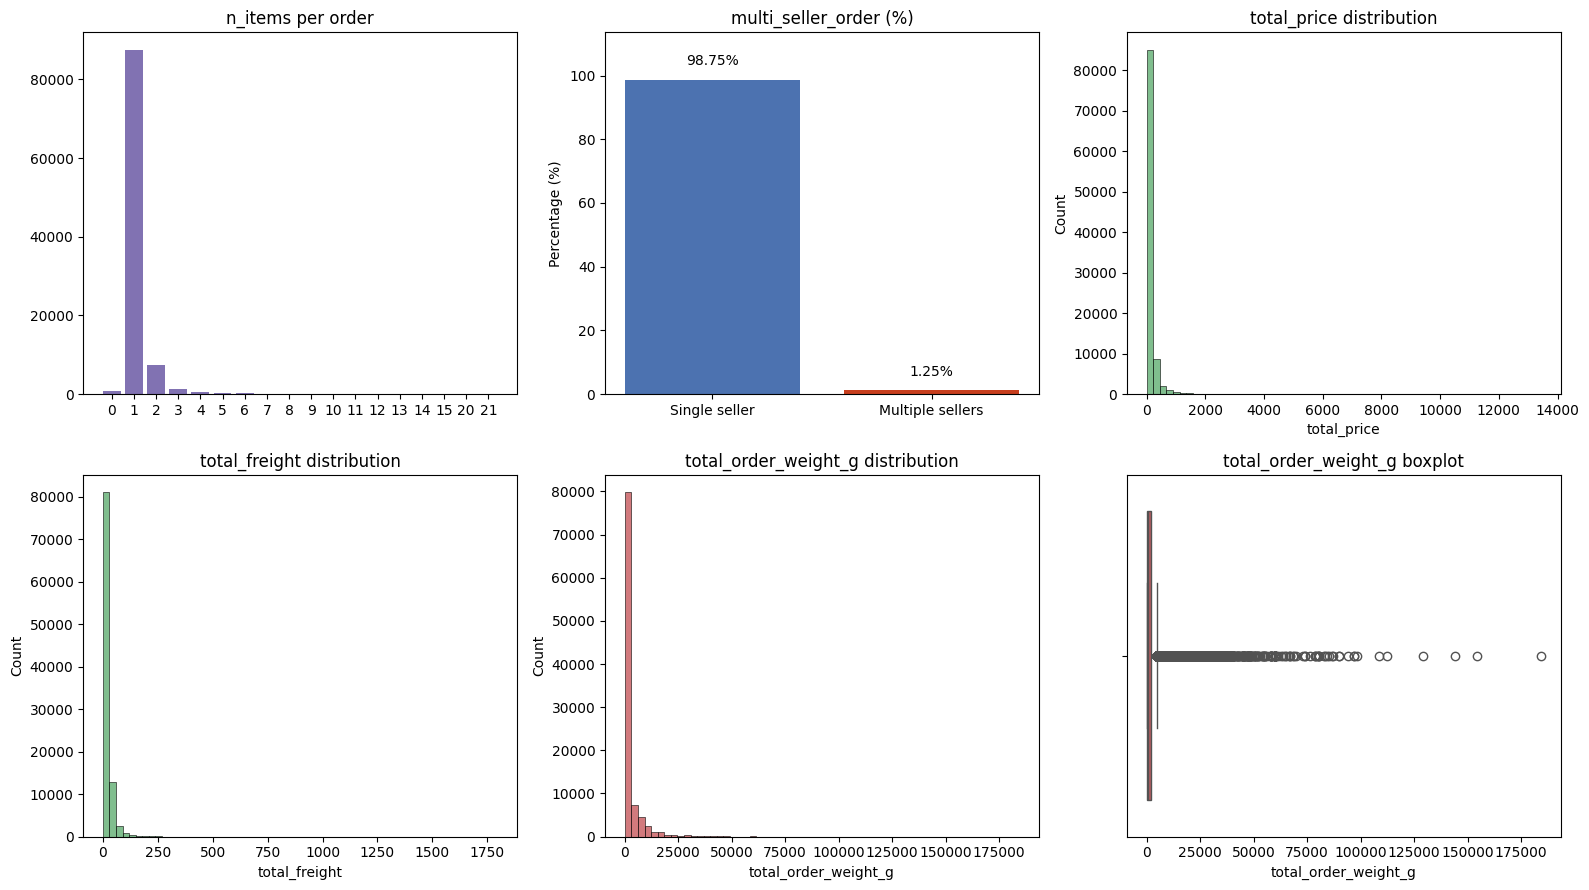

            n_items   total_price  total_freight  total_order_weight_g
count  98017.000000  98017.000000   98017.000000          98017.000000
mean       1.132528    136.813058      22.633802           2377.443290
std        0.545554    210.643878      21.687992           4774.380804
min        0.000000      0.000000       0.000000              0.000000
25%        1.000000     45.000000      13.710000            300.000000
50%        1.000000     85.000000      17.070000            745.000000
75%        1.000000    149.900000      23.910000           2050.000000
max       21.000000  13440.000000    1794.960000         184400.000000


total_price skewness            : 9.75
total_freight skewness          : 12.04
total_order_weight_g skewness   : 6.54


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))

# number of items per order
n_items_counts = order_analysis_df['n_items'].value_counts().sort_index()
axes[0,0].bar(n_items_counts.index.astype(str), n_items_counts.values, color='#8172B2')
axes[0,0].set_title('n_items per order')

# single vs multi seller
multi_counts = order_analysis_df['multi_seller_order'].value_counts()
total_orders = multi_counts.sum()

single_pct = (multi_counts.get(False, 0) / total_orders * 100) if total_orders > 0 else 0
multi_pct = (multi_counts.get(True, 0) / total_orders * 100) if total_orders > 0 else 0

bars = axes[0,1].bar(
    ['Single seller', 'Multiple sellers'], 
    [single_pct, multi_pct], 
    color=['#4C72B0', '#C73E1D']
)
axes[0,1].set_title('multi_seller_order (%)')
axes[0,1].set_ylabel('Percentage (%)')

max_pct = max(single_pct, multi_pct)
axes[0,1].set_ylim(0, max_pct * 1.15)
axes[0,1].bar_label(bars, fmt='%.2f%%', padding=8)

# total price distribution
sns.histplot(order_analysis_df['total_price'], bins=60, ax=axes[0,2], color='#55A868')
axes[0,2].set_title('total_price distribution')

# total freight distribution
sns.histplot(order_analysis_df['total_freight'], bins=60, ax=axes[1,0], color='#55A868')
axes[1,0].set_title('total_freight distribution')

# total order weight distribution
sns.histplot(order_analysis_df['total_order_weight_g'].dropna(), bins=60, ax=axes[1,1], color='#C44E52')
axes[1,1].set_title('total_order_weight_g distribution')

# order weight boxplot
sns.boxplot(x=order_analysis_df['total_order_weight_g'].dropna(), ax=axes[1,2], color='#C44E52')
axes[1,2].set_title('total_order_weight_g boxplot')

plt.tight_layout()
plt.show()

print(order_analysis_df[['n_items','total_price','total_freight','total_order_weight_g']].describe())
print("\n")
print('total_price skewness            :', order_analysis_df['total_price'].skew().round(2))
print('total_freight skewness          :', order_analysis_df['total_freight'].skew().round(2))
print('total_order_weight_g skewness   :', order_analysis_df['total_order_weight_g'].skew().round(2))


The majority of orders contain a single item from a single seller (multi-seller orders 1.25%). `total_price` and `total_freight` are both heavily right-skewed, and `total_order_weight_g` shows the same pattern. a dense cluster of light orders with a long tail of heavy ones, which makes physical sense (most items are small consumer goods, with occasional furniture/appliance-scale outliers).


### **1.1.3 Date-derived timing: `approval_delay_hours`, `promised_window_days`, `seller_dispatch_window_days`**

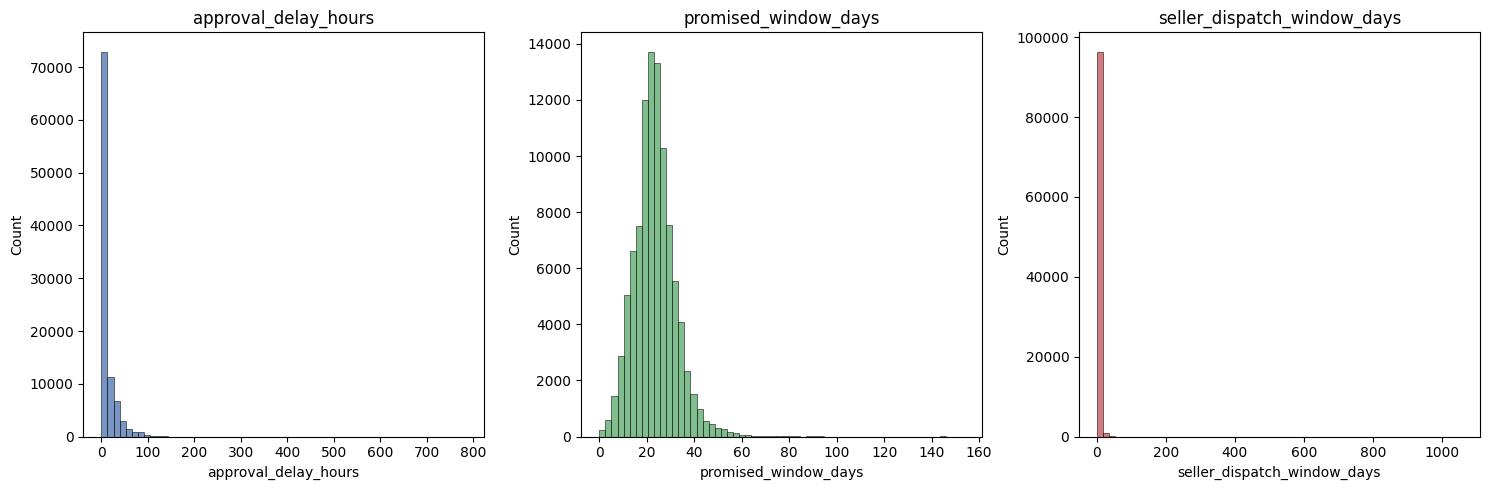

       approval_delay_hours  promised_window_days  seller_dispatch_window_days
count          97871.000000          97871.000000                 97247.000000
mean               9.712215             23.373188                     6.626682
std               19.534577              8.830811                     6.693739
min                0.000000              0.020498                     2.004236
25%                0.214167             18.008553                     5.006811
50%                0.337778             22.812350                     6.011771
75%               13.619167             28.117824                     7.164057
max              784.045556            153.576030                  1056.041667


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, col, color in zip(axes, ['approval_delay_hours','promised_window_days','seller_dispatch_window_days'],
                            ['#4C72B0','#55A868','#C44E52']):
    sns.histplot(order_analysis_df[col].dropna(), bins=60, ax=ax, color=color)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print(order_analysis_df[['approval_delay_hours','promised_window_days','seller_dispatch_window_days']].describe())


In [15]:
print("Lead time (promised_window_days)")
for p in [5,10,25,50,75,90,95]:
    print(f"  p{p}: {order_analysis_df['promised_window_days'].quantile(p/100):.1f} days")


Lead time (promised_window_days)
  p5: 10.1 days
  p10: 12.6 days
  p25: 18.0 days
  p50: 22.8 days
  p75: 28.1 days
  p90: 33.9 days
  p95: 38.2 days


most of the `approval_delay_hours` are located near zero with a long tail, `promised_window_days` centered around 22-23 days, `seller_dispatch_window_days` tighter around 6 days.

### **1.1.4 `purchase_month` and `purchase_dow`**

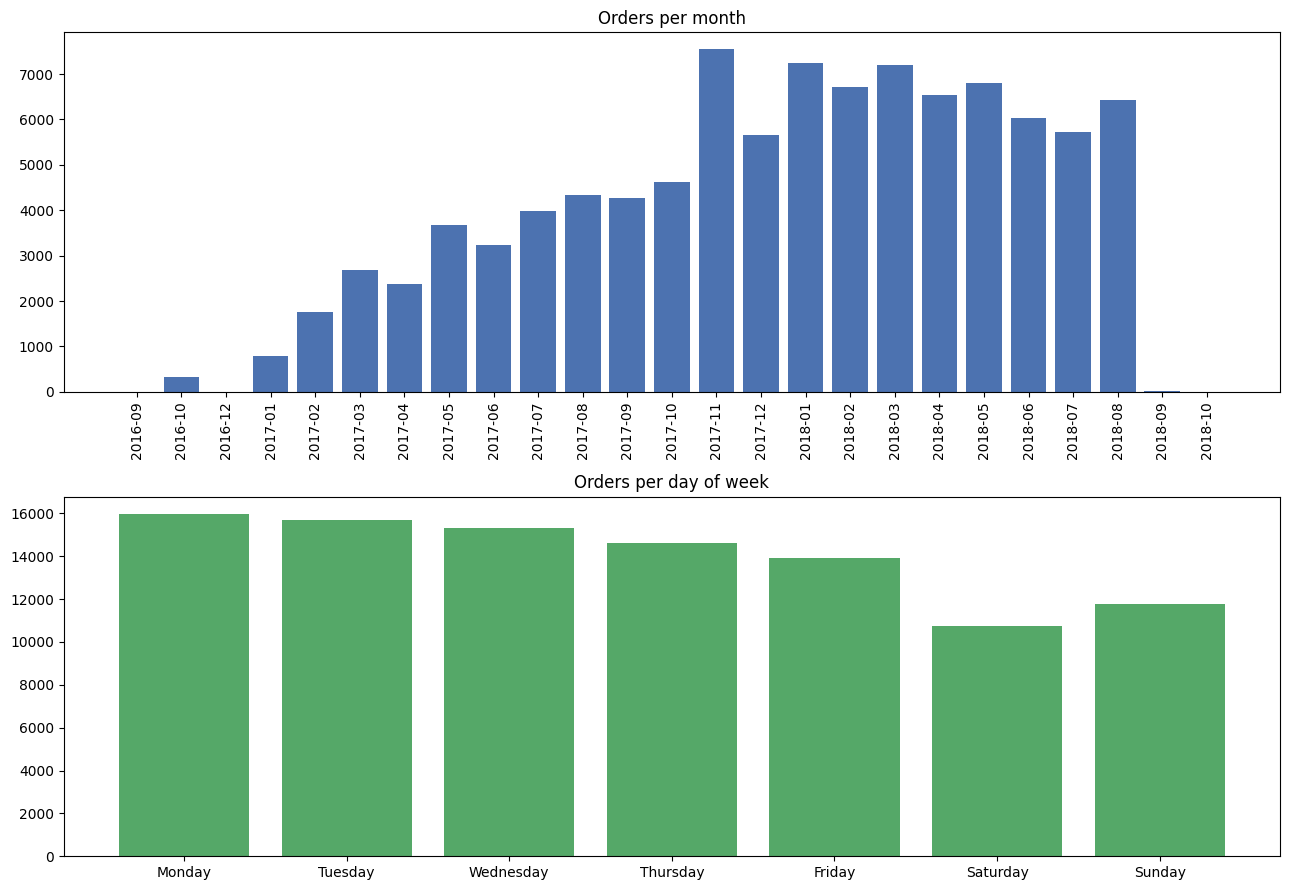

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13,9))

month_counts = order_analysis_df['purchase_month'].value_counts().sort_index()
axes[0].bar(month_counts.index, month_counts.values, color='#4C72B0')
axes[0].set_title('Orders per month')
axes[0].tick_params(axis='x', rotation=90)

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = order_analysis_df['purchase_dow'].value_counts().reindex(dow_order)
axes[1].bar(dow_counts.index, dow_counts.values, color='#55A868')
axes[1].set_title('Orders per day of week')

plt.tight_layout()
plt.show()


Same seasonal pattern as before (steady growth into a November 2017
peak, consistent with Black Friday), and fairly even volume across days of
the week with a mild weekend dip.


### **1.1.5 Payment behavior: `total_payment_value`, `payment_installments`, `payment_type`, `n_vouchers`, `voucher_value`**

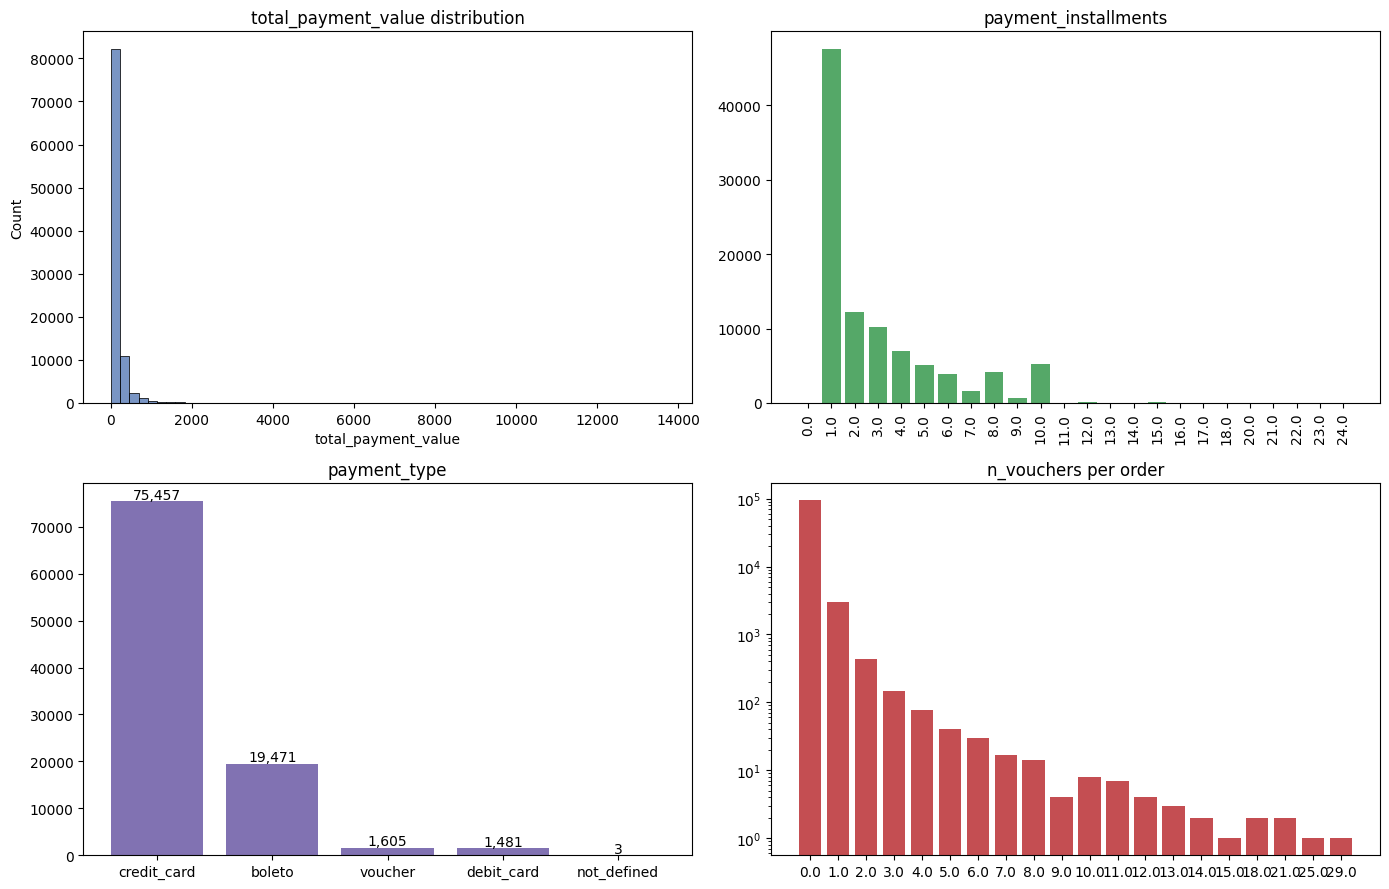

count    98017.000000
mean       161.131636
std        222.447678
min          0.000000
25%         62.010000
50%        105.290000
75%        177.010000
max      13664.080000
Name: total_payment_value, dtype: float64

payment_type breakdown:
payment_type
credit_card    76.98
boleto         19.86
voucher         1.64
debit_card      1.51
not_defined     0.00
Name: count, dtype: float64

Orders using at least one voucher: 3.90%
Orders with a nonzero voucher_value: 3.90%


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14,9))

sns.histplot(order_analysis_df['total_payment_value'], bins=60, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('total_payment_value distribution')

installments_counts = order_analysis_df['payment_installments'].value_counts().sort_index()
axes[0,1].bar(installments_counts.index.astype(str), installments_counts.values, color='#55A868')
axes[0,1].set_title('payment_installments')
axes[0,1].tick_params(axis='x', rotation=90)

payment_type_counts = order_analysis_df['payment_type'].value_counts()
axes[1,0].bar(payment_type_counts.index, payment_type_counts.values, color='#8172B2')
axes[1,0].set_title('payment_type')
for i, v in enumerate(payment_type_counts.values):
    axes[1,0].text(i, v+500, f'{v:,}', ha='center')

n_voucher_counts = order_analysis_df['n_vouchers'].value_counts().sort_index()
axes[1,1].bar(n_voucher_counts.index.astype(str), n_voucher_counts.values, color='#C44E52')
axes[1,1].set_title('n_vouchers per order')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

print(order_analysis_df['total_payment_value'].describe())
print()
print('payment_type breakdown:')
print((payment_type_counts / payment_type_counts.sum() * 100).round(2))
print()
print(f"Orders using at least one voucher: {(order_analysis_df['n_vouchers']>0).mean():.2%}")
print(f"Orders with a nonzero voucher_value: {(order_analysis_df['voucher_value']>0).mean():.2%}")


`total_payment_value` is right-skewed like `total_price` (expected, since it's closely related). Most orders use a single installment or a small handful, with a long tail out to 24. `credit_card` dominates payment type, and the `not_defined` category are present but in small numbers (a genuine anomaly, not a real payment method, worth remembering rather than treating as a normal 5th category). Voucher usage is rare where only about 3.9% of orders use one at all, so `n_vouchers` and `voucher_value` are both heavily zero-inflated

### **1.1.6 `review_score` and `has_review_comment` (context variables, not the modeling target)**

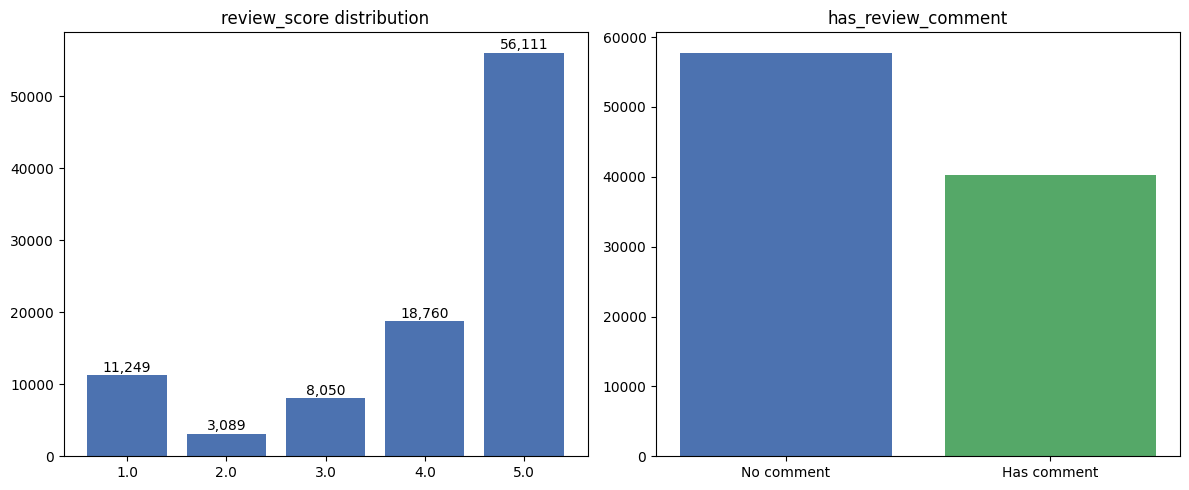

review_score
1.0    11249
2.0     3089
3.0     8050
4.0    18760
5.0    56111
Name: count, dtype: int64

Orders missing a review_score entirely: 758 (0.77%)
Orders with a written comment: 41.03%


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

review_counts = order_analysis_df['review_score'].value_counts().sort_index()
axes[0].bar(review_counts.index.astype(str), review_counts.values, color='#4C72B0')
axes[0].set_title('review_score distribution')
for i, v in enumerate(review_counts.values):
    axes[0].text(i, v+500, f'{v:,}', ha='center')

comment_counts = order_analysis_df['has_review_comment'].value_counts()
axes[1].bar(['No comment','Has comment'], [comment_counts.get(False,0), comment_counts.get(True,0)], color=['#4C72B0','#55A868'])
axes[1].set_title('has_review_comment')

plt.tight_layout()
plt.show()

print(review_counts)
print()
print(f"Orders missing a review_score entirely: {order_analysis_df['review_score'].isna().sum()} ({order_analysis_df['review_score'].isna().mean():.2%})")
print(f"Orders with a written comment: {order_analysis_df['has_review_comment'].mean():.2%}")


The same 5-star-dominant, right-skewed shape found throughout this project (roughly 58% 5-star with 15% at 1-2 stars). Fewer than half of orders come with a written comment meaning that most customers rate but don't write anything.


### **1.1.7 `product_category_name_english` and product dimensions (item-level)**

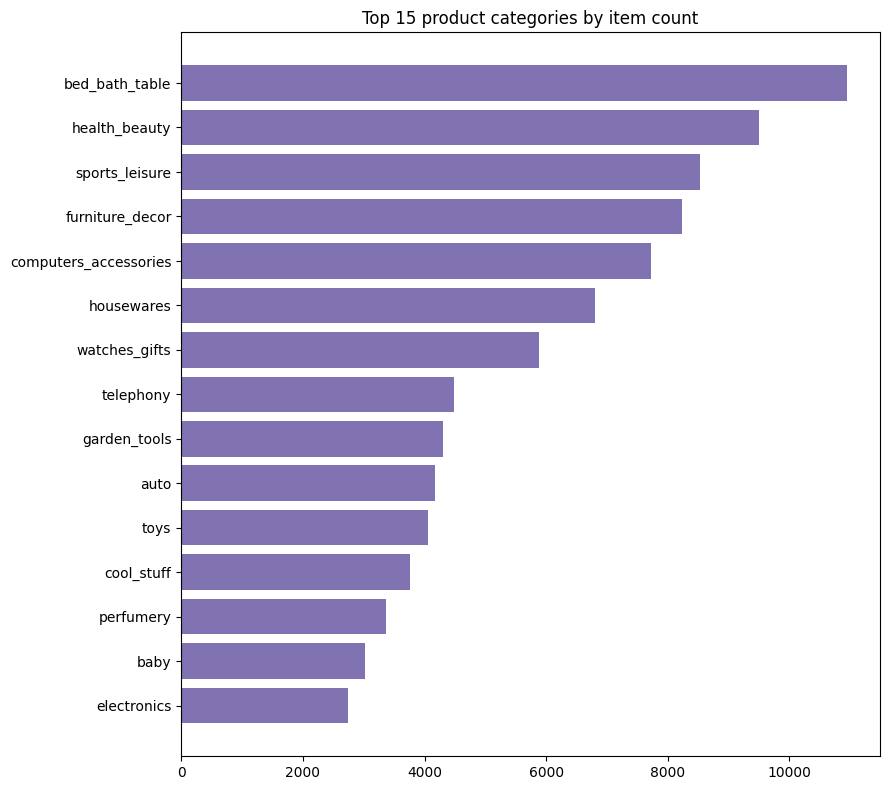

Total distinct categories: 71
Items missing a category: 2361 (2.11%)


In [19]:
fig, ax = plt.subplots(figsize=(9,8))
top_categories = item_analysis_df['product_category_name_english'].value_counts().head(15)
ax.barh(top_categories.index[::-1], top_categories.values[::-1], color='#8172B2')
ax.set_title('Top 15 product categories by item count')
plt.tight_layout()
plt.show()

print(f"Total distinct categories: {item_analysis_df['product_category_name_english'].nunique()}")
print(f"Items missing a category: {item_analysis_df['product_category_name_english'].isna().sum()} ({item_analysis_df['product_category_name_english'].isna().mean():.2%})")


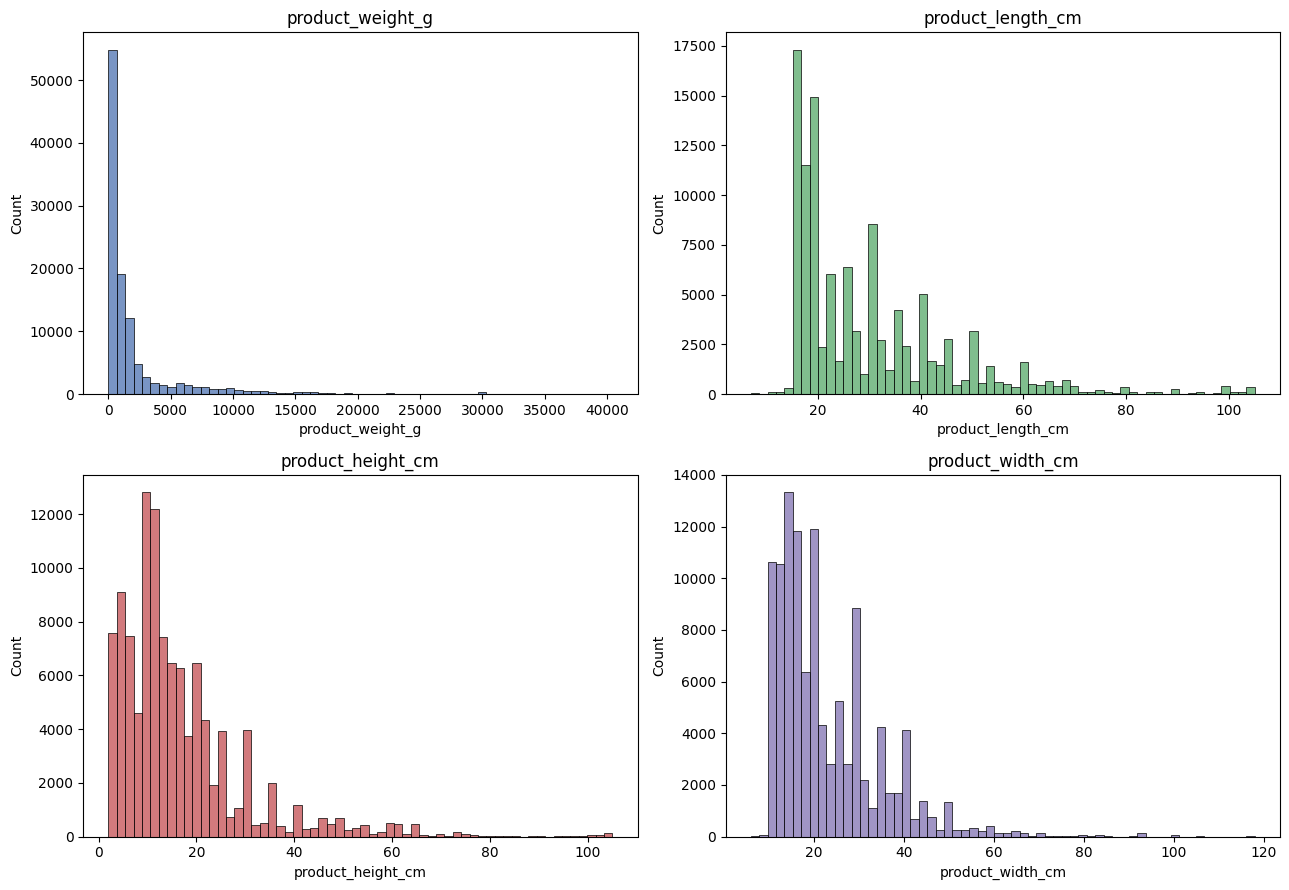

       product_weight_g  product_length_cm  product_height_cm  product_width_cm
count     110989.000000      110989.000000      110989.000000     110989.000000
mean        2099.576165          30.176513          16.609304         23.005974
std         3762.890474          16.166217          13.459082         11.714063
min            0.000000           7.000000           2.000000          6.000000
25%          300.000000          18.000000           8.000000         15.000000
50%          700.000000          25.000000          13.000000         20.000000
75%         1800.000000          38.000000          20.000000         30.000000
max        40425.000000         105.000000         105.000000        118.000000


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))
for ax, col, color in zip(axes.flat, ['product_weight_g','product_length_cm','product_height_cm','product_width_cm'],
                            ['#4C72B0','#55A868','#C44E52','#8172B2']):
    sns.histplot(item_analysis_df[col].dropna(), bins=60, ax=ax, color=color)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print(item_analysis_df[['product_weight_g','product_length_cm','product_height_cm','product_width_cm']].describe())


`bed_bath_table`, `health_beauty`, and `sports_leisure` lead the category distribution which is consistent with a general consumer marketplace, with 71 distinct categories in total and a long tail of niche ones. All four dimension columns are right-skewed with the same pattern seen throughout this dataset implying that most products are small, with a minority of large/heavy outliers (furniture, appliances) pulling the tail.


### **1.1.8 Customer geography and repeat-purchase behavior**

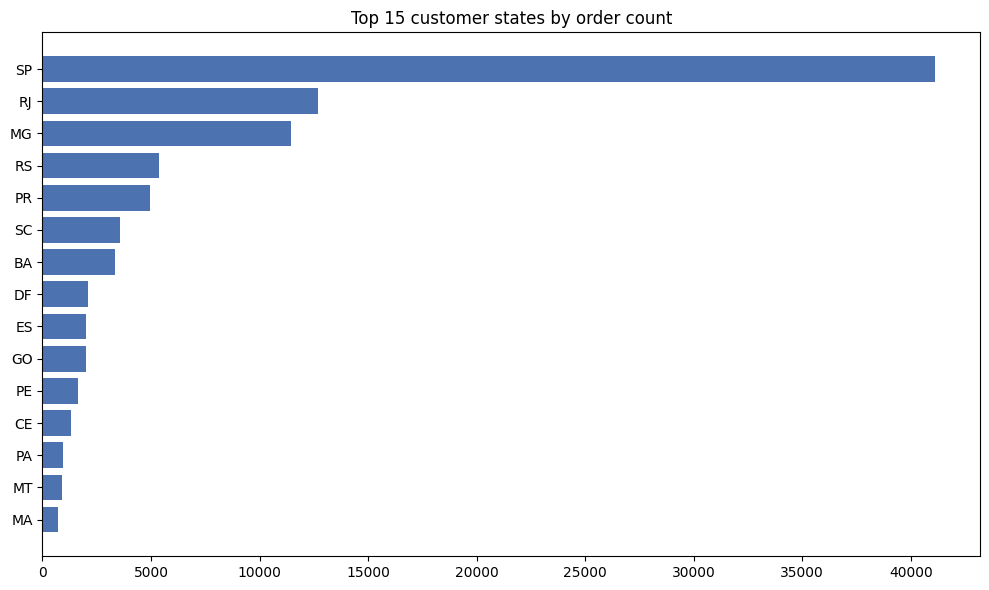

Distinct customer states: 27


In [21]:
fig, ax = plt.subplots(figsize=(10,6))
top_states = order_analysis_df['customer_geo_state'].value_counts().head(15)
ax.barh(top_states.index[::-1], top_states.values[::-1], color='#4C72B0')
ax.set_title('Top 15 customer states by order count')
plt.tight_layout()
plt.show()

print(f"Distinct customer states: {order_analysis_df['customer_geo_state'].nunique()}")


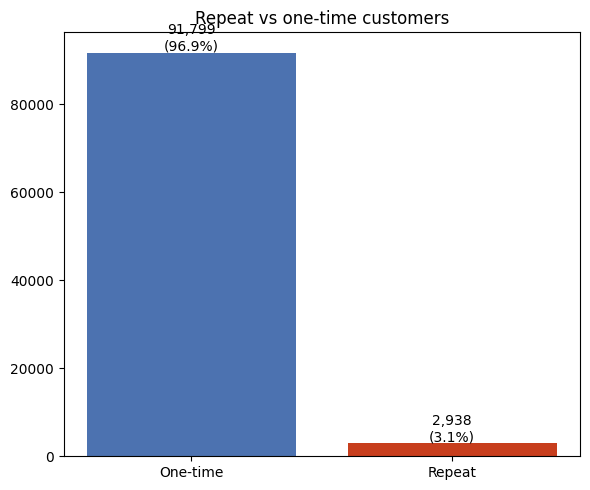

In [22]:
fig, ax = plt.subplots(figsize=(6,5))
repeat_counts = order_analysis_df.drop_duplicates('customer_unique_id')['is_repeat_customer'].value_counts()
ax.bar(['One-time','Repeat'], [repeat_counts.get(False,0), repeat_counts.get(True,0)], color=['#4C72B0','#C73E1D'])
ax.set_title('Repeat vs one-time customers')
for i, v in enumerate([repeat_counts.get(False,0), repeat_counts.get(True,0)]):
    ax.text(i, v+500, f'{v:,}\n({v/repeat_counts.sum():.1%})', ha='center')
plt.tight_layout()
plt.show()


Customer orders are heavily concentrated in SP (Sao Paulo) expected given Brazil's population distribution. Repeat customers are rare (3.1% of customers place more than one order)

### **1.1.9 Seller geography (item-level)**

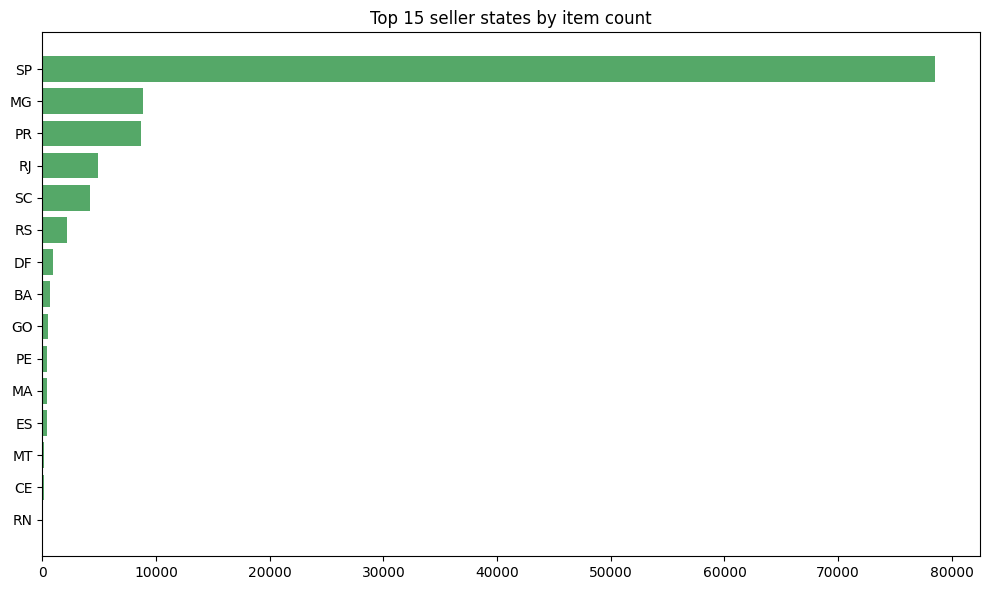

Distinct seller states: 22


In [23]:
fig, ax = plt.subplots(figsize=(10,6))
top_seller_states = item_analysis_df['seller_geo_state'].value_counts().head(15)
ax.barh(top_seller_states.index[::-1], top_seller_states.values[::-1], color='#55A868')
ax.set_title('Top 15 seller states by item count')
plt.tight_layout()
plt.show()

print(f"Distinct seller states: {item_analysis_df['seller_geo_state'].nunique()}")


Sellers are even more concentrated than customers which mostly clustered in SP and a handful of other major states, with far fewer distinct seller states represented overall than customer states. This asymmetry (many customer locations, few seller hubs) is exactly what makesc seller-customer distance a plausible logistics risk factor worth testing in the bivariate analysis (most shipments are travelling from a small number of origin points to a much wider spread of destinations)


## **1.2 Bivariate Analysis**


In [24]:
# make is_late and attach it to the existing order-level and item-level tables
target_source = df.drop_duplicates('order_id')[['order_id', 'order_status',
                                                   'order_delivered_customer_date',
                                                   'order_estimated_delivery_date']].copy()
target_source['is_late'] = (
    target_source['order_delivered_customer_date'].dt.normalize() >
    target_source['order_estimated_delivery_date'].dt.normalize()
)

# order-level bivariate table (restrict to delivered orders (the only ones is_late is defined for))
biv_df = order_analysis_df.merge(
    target_source[['order_id', 'order_status', 'is_late']].rename(columns={'order_status':'order_status_check'}),
    on='order_id'
)
biv_df = biv_df[biv_df['order_status_check']=='delivered'].drop(columns=['order_status_check'])

# item-level bivariate table (same restriction)
biv_item_df = item_analysis_df.merge(target_source[['order_id','order_status','is_late']], on='order_id')
biv_item_df = biv_item_df[biv_item_df['order_status']=='delivered'].drop(columns=['order_status'])

print(f"biv_df (order-level): {biv_df.shape}, late rate: {biv_df['is_late'].mean():.2%}")
print(f"biv_item_df (item-level): {biv_item_df.shape}")


biv_df (order-level): (95070, 28), late rate: 6.84%
biv_item_df (item-level): (108566, 12)


In [25]:
# Shared helper: Chi-square test + Bonferroni-corrected adjusted standardized residuals (z-scores).
# A plain chi-square only tells us THAT categories differ, not WHICH ones drive it
# z-scores answer that, used throughout this section for every categorical-vs-is_late test
def chi_square_with_zscores(contingency):
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.values.sum()
    row_totals = contingency.sum(axis=1).values[:, np.newaxis]
    col_totals = contingency.sum(axis=0).values
    r_prop = row_totals / n
    c_prop = col_totals / n
    se = np.sqrt(expected * (1 - r_prop) * (1 - c_prop))
    z = pd.DataFrame((contingency.values - expected) / se, index=contingency.index, columns=contingency.columns)
    return chi2, p_val, dof, z

def bonferroni_z_crit(k):
    return stats.norm.ppf(1 - 0.05 / (2*k))


### **1.2.1 Payment Factors**

#### 1.2.1.1 `payment_type` vs `is_late`
payment method could plausibly relate to fulfillment speed. for example, `boleto` (a Brazilian bank-slip payment) only clears once physically paid, which could delay order processing start compared to an instant credit card charge.


In [26]:
ct_payment = pd.crosstab(biv_df['payment_type'], biv_df['is_late']).T
ct_payment.index = ['On-Time','Late']
print(ct_payment)

payment_type  boleto  credit_card  debit_card  voucher
On-Time        17483        68323        1362     1395
Late            1401         4942          77       87


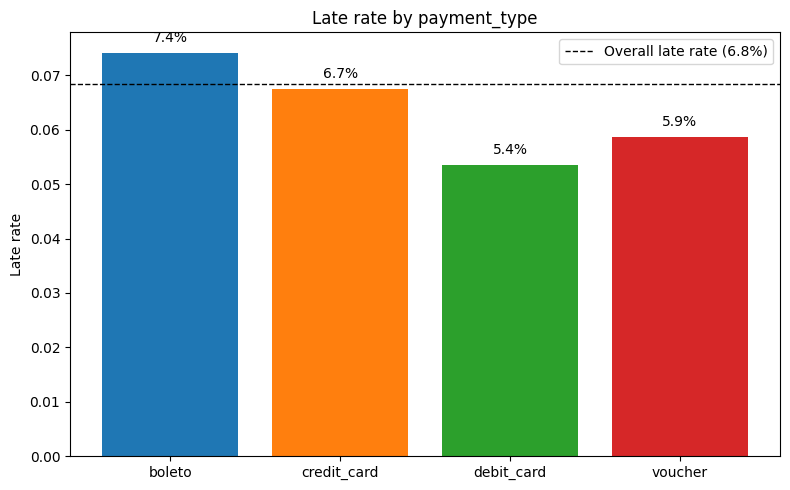

In [27]:
late_rate = ct_payment.loc['Late'] / ct_payment.sum()
overall_rate = ct_payment.loc['Late'].sum() / ct_payment.values.sum()
colors = sns.color_palette('tab10', n_colors=len(late_rate))

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(late_rate.index.astype(str), late_rate.values, color=colors)
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1,
           label=f'Overall late rate ({overall_rate:.1%})')
for i, v in enumerate(late_rate.values):
    ax.text(i, v + 0.002, f'{v:.1%}', ha='center')
ax.set_title('Late rate by payment_type')
ax.set_ylabel('Late rate')
ax.legend()
plt.tight_layout()
plt.show()

We will perform a statistical hypothesis test (Chi-square Test of Independence) to test: is there a significant association between payment_type and an order being late.

Hypotheses:
- $H_0$: `is_late` is independent of `payment_type`.
- $H_1$: `is_late` is significantly associated with `payment_type`.


In [28]:
chi2, p_val, dof, z = chi_square_with_zscores(ct_payment)
z_crit = bonferroni_z_crit(k=ct_payment.shape[1])

print(f"Chi2-Statistic : {chi2:.4f}")
print(f"P-Value        : {p_val}")
print(f"dof            : {dof}")
print(f"Bonferroni z_crit (k={ct_payment.shape[1]}): {z_crit:.3f}")
print()
print("Adjusted standardized residuals (Late row) -- |z| > z_crit means that category")
print("meaningfully drives the association, not just the overall chi-square result:")
print(z.loc['Late'].round(2))

if p_val < 0.05:
    print("\nConclusion     : Reject H0! There IS a significant association between")
    print("                 payment_type and an order being late.")
else:
    print("\nConclusion     : Fail to reject H0. No significant association found.")


Chi2-Statistic : 18.1434
P-Value        : 0.0004108832433476727
dof            : 3
Bonferroni z_crit (k=4): 2.498

Adjusted standardized residuals (Late row) -- |z| > z_crit means that category
meaningfully drives the association, not just the overall chi-square result:
payment_type
boleto         3.49
credit_card   -2.22
debit_card    -2.26
voucher       -1.50
Name: Late, dtype: float64

Conclusion     : Reject H0! There IS a significant association between
                 payment_type and an order being late.


The test uses a threshold (Bonferroni z_crit = 2.498). If a payment type's score is higher than (2.498) or lower than (-2.498), that specific category is heavily skewing the results.

Boleto has a high positive residual 3.49 > 2.498 means there are significantly more late orders than expected when customers pay with a boleto. On the other hand, credit_card (-2.22) & debit_card (-2.26) have negative scores that show these methods have fewer late orders than average, but because they don't quite cross the 2.498 threshold, they are not considered statistically definitive drivers on their own.


#### 1.2.1.2 `payment_installments` (grouped) vs `is_late`

number of installments is a plausible represantation for purchase size/consideration. a large, more-deliberated purchase might be handled differently in fulfillment than a small, instant one. Installments only apply to credit card payments, so non-credit-card orders are grouped into their own "Instant Cash/Upfront" category rather than dropped. See table:

| Bin Name | Installment Range | What it actually represents |
|---|---|---|
| Instant Cash/Upfront | - | Non-credit payments (Boleto, Debit, Voucher). |
| Credit Upfront | 1 | Credit card users who chose to pay the full balance in one cycle. |
| Short-Term | 2 - 4 | Split financing over a brief 2–4 month window. |
| Mid-Term | 5 - 10 | Extended payment plans (heavily concentrated at 6 and 10 months). |
| Long-Term | 11 - 24 | Long-term high-value financing (1 to 2 years). |

In [29]:
bins = [-1, 1, 4, 10, 24]
labels = ['Credit Upfront', 'Short-Term', 'Mid-Term', 'Long-Term']

biv_df['installment_group'] = pd.cut(biv_df['payment_installments'], bins=bins, labels=labels)
biv_df['installment_group'] = biv_df['installment_group'].cat.add_categories(['Instant Cash/Upfront'])
biv_df.loc[biv_df['payment_type'] != 'credit_card', 'installment_group'] = 'Instant Cash/Upfront'

ct_installments = pd.crosstab(biv_df['installment_group'], biv_df['is_late']).T
ct_installments.index = ['On-Time','Late']
print(ct_installments)


installment_group  Credit Upfront  Short-Term  Mid-Term  Long-Term  Instant Cash/Upfront
On-Time                     22851       26593     18580        299                 20240
Late                         1470        1983      1462         27                  1565


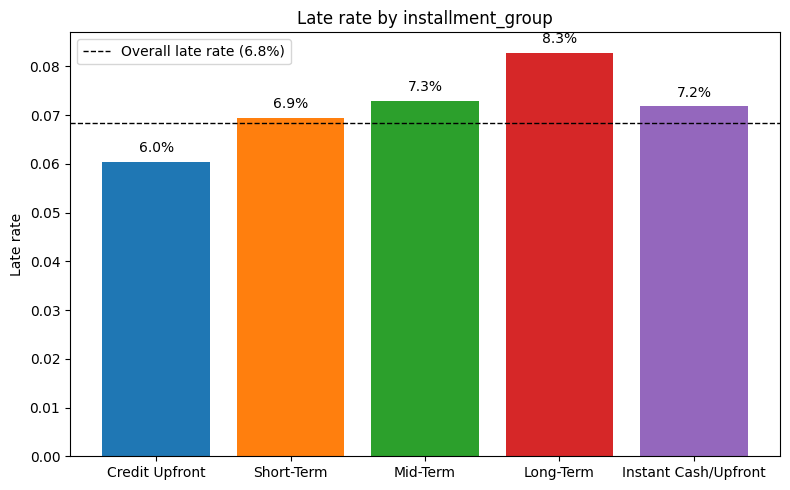

In [30]:
late_rate = ct_installments.loc['Late'] / ct_installments.sum()
overall_rate = ct_installments.loc['Late'].sum() / ct_installments.values.sum()
colors = sns.color_palette('tab10', n_colors=len(late_rate))

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(late_rate.index.astype(str), late_rate.values, color=colors)
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1,
           label=f'Overall late rate ({overall_rate:.1%})')
for i, v in enumerate(late_rate.values):
    ax.text(i, v + 0.002, f'{v:.1%}', ha='center')
ax.set_title('Late rate by installment_group')
ax.set_ylabel('Late rate')
ax.legend()
plt.tight_layout()
plt.show()

We will perform a statistical hypothesis test (Chi-square Test of Independence) to test: is there a significant association between payment installment group and an order being late.

Hypotheses:
- $H_0$: `is_late` is independent of `installment_group`.
- $H_1$: `is_late` is significantly associated with `installment_group`.


In [31]:
chi2, p_val, dof, z = chi_square_with_zscores(ct_installments)
z_crit = bonferroni_z_crit(k=ct_installments.shape[1])

print(f"Chi2-Statistic : {chi2:.4f}")
print(f"P-Value        : {p_val}")
print(f"Bonferroni z_crit (k={ct_installments.shape[1]}): {z_crit:.3f}")
print()
print(z.loc['Late'].round(2))

if p_val < 0.05:
    print("\nConclusion     : Reject H0! There IS a significant association between")
    print("                 installment group and an order being late.")
else:
    print("\nConclusion     : Fail to reject H0. No significant association found.")


Chi2-Statistic : 36.0509
P-Value        : 2.824709385149328e-07
Bonferroni z_crit (k=5): 2.576

installment_group
Credit Upfront         -5.73
Short-Term              0.76
Mid-Term                2.84
Long-Term               1.03
Instant Cash/Upfront    2.22
Name: Late, dtype: float64

Conclusion     : Reject H0! There IS a significant association between
                 installment group and an order being late.


Credit Upfront (1 installment) is strongly associated with being on-time. Mid-Term installments (5-10 payments) stand out as a genuine, Bonferroni-significant risk factor meaning that it is a positive association with lateness, distinct from and more reliable than the non credit-card ("Instant Cash/Upfront") category, which sits right at the edge of significance


### **1.2.2 Seller Fulfillment Factors**

#### 1.2.2.1 Seller lateness to `shipping_limit_date` vs `is_late`

`shipping_limit_date` is the seller's own deadline to hand the item to the carrier. If the seller misses that internal deadline, does the order actually end up late to the customer? This tests whether seller-side delay is a meaningful driver of the final outcome, or whether the carrier has enough slack to absorb a late handoff.


In [32]:
# shipping_limit_date and order_delivered_carrier_date aren't kept in order_analysis_df
# (only their derived difference, seller_dispatch_window_days, is)
carrier_dates = df.drop_duplicates('order_id')[['order_id','shipping_limit_date','order_delivered_carrier_date']]
biv_df = biv_df.merge(carrier_dates, on='order_id')

biv_df['seller_late_to_carrier'] = biv_df['shipping_limit_date'] < biv_df['order_delivered_carrier_date']

ct_seller = pd.crosstab(biv_df['seller_late_to_carrier'], biv_df['is_late']).T
ct_seller.index = ['On-Time','Late']
ct_seller.columns = ['Seller on-time to carrier','Seller late to carrier']
print(ct_seller)
print()

seller_late_share = biv_df.loc[biv_df['is_late'], 'seller_late_to_carrier'].mean()
print(f"Among LATE orders, sellers who also missed their own carrier deadline: {seller_late_share:.2%}")


         Seller on-time to carrier  Seller late to carrier
On-Time                      81694                    6869
Late                          4694                    1813

Among LATE orders, sellers who also missed their own carrier deadline: 27.86%


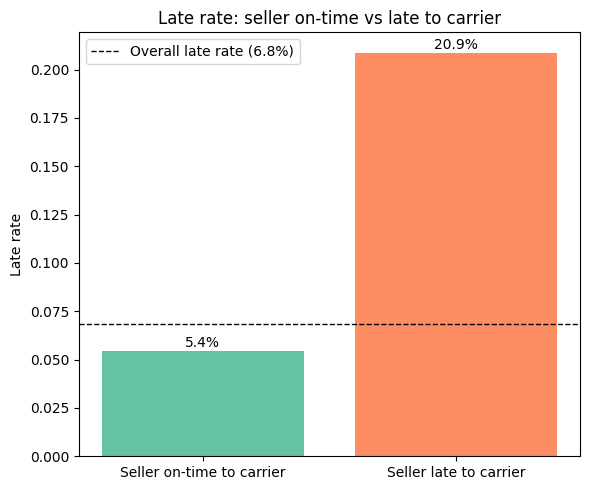

In [33]:
late_rate = ct_seller.loc['Late'] / ct_seller.sum()
overall_rate = ct_seller.loc['Late'].sum() / ct_seller.values.sum()
colors = sns.color_palette('Set2', n_colors=len(late_rate))

fig, ax = plt.subplots(figsize=(6,5))
ax.bar(late_rate.index.astype(str), late_rate.values, color=colors)
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1,
           label=f'Overall late rate ({overall_rate:.1%})')
for i, v in enumerate(late_rate.values):
    ax.text(i, v + 0.002, f'{v:.1%}', ha='center')
ax.set_title('Late rate: seller on-time vs late to carrier')
ax.set_ylabel('Late rate')
ax.legend()
plt.tight_layout()
plt.show()

We will perform a statistical hypothesis test (Chi-square Test of Independence) to test: is there a significant association between the seller missing their own shipping deadline and the order being late to the customer.

Hypotheses:
- $H_0$: `is_late` is independent of whether the seller was late handing the order to the carrier.
- $H_1$: `is_late` is significantly associated with whether the seller was late handing the order to the carrier.


In [34]:
chi2, p_val, dof, expected = stats.chi2_contingency(ct_seller)

print(f"Chi2-Statistic : {chi2:.4f}")
print(f"P-Value        : {p_val}")

if p_val < 0.05:
    print("\nConclusion     : Reject H0! There IS a significant association between seller")
    print("                 lateness to the carrier and the order being late overall.")
else:
    print("\nConclusion     : Fail to reject H0. No significant association found.")


Chi2-Statistic : 2950.5895
P-Value        : 0.0

Conclusion     : Reject H0! There IS a significant association between seller
                 lateness to the carrier and the order being late overall.


Only a minority of late orders actually involved a seller who was late to the carrier. Most late orders had the seller meet their own deadline (maybe the delay happened somewhere else like in transit), consistent with earlier findings elsewhere in this project that the shipping/transit leg matters more than seller dispatch speed. Seller lateness is a strong risk factor when it happens, but not the dominant explanation for most late deliveries.


### **1.2.3 Geographic Factors**

#### 1.2.3.1 Seller-customer distance vs `is_late`

physical shipping distance is a direct, mechanistic candidate for delivery risk. More distance plausibly means more transit
time and more chances for a delay to accumulate. Seller location is item-level (a multi-seller order has more than one seller location), so this uses `biv_item_df`, matching how seller geography was already scoped in the univariate section.

Also the data right now doesnt have the distance between seller and customer, for that reason we would calculate the true physical distance between them using the central latitude and longtitude of each zipcode. to get this true distance what we would do is implement a formula called **Haversine Formula**. This formula would determines the great-circle distance between two points on a sphere given their longitudes and latitudes.  
$$
\begin{aligned}
\text{hav}\theta & = \text{hav}(\Delta\varphi) + \cos(\varphi_1)\cos(\varphi_2)\text{hav}(\Delta\lambda)\\
                 & = \text{hav}(\Delta\varphi) + (1-\text{hav}(\Delta\varphi)-\text{hav}(2\varphi_m))\cdot\text{hav}(\Delta\lambda)\\
                 & =\sin^2\left(\frac{\Delta\varphi}{2}\right) + \left(1-\sin^2\left(\frac{\Delta\varphi}{2}-\sin^2(\varphi_m)\right)\right)\cdot \sin^2\left(\frac{\Delta\lambda}{2}\right)\\
                 & = \sin^2\left(\frac{\Delta\varphi}{2}\right) + \cos\varphi_1 \cdot \cos\varphi_2 \cdot \sin^2\left(\frac{\Delta\lambda}{2}\right)\\
                 & = \sin^2\left(\frac{\Delta\varphi}{2}\right) \cdot \cos^2\left(\frac{\Delta\lambda}{2}\right) + \cos^2(\varphi_m) \cdot \sin^2\left(\frac{\Delta\lambda}{2}\right)\\
                 & = \frac{1-cos(\Delta\varphi) + \cos\varphi_1 \cdot \cos\varphi_2 \cdot (1-cos(\Delta\lambda))}{2}\\
               c & = 2\cdot\arcsin(\sqrt{\text{hav}\theta})\\
               d & = R\cdot c
\end{aligned}
$$
**Where:**
- $\varphi_1, \lambda_1$ = Coordinates of Point 1 (e.g., Seller)
- $\varphi_2, \lambda_2$ = Coordinates of Point 2 (e.g., Customer)
- $\Delta \varphi = \varphi_2 - \varphi_1$ (Difference in latitude)
- $\Delta \lambda = \lambda_2 - \lambda_1$ (Difference in longitude)
- $\varphi_m$ = Mean latitude between the two points
- $R$ = Earth's radius. Typically 6,371 km for kilometers (or 3,956 miles if you need imperial).


**The Core Concept (Step-by-Step Breakdown)**  
If you look at the math, the formula does three fundamental things:  
- **Converts Degrees to Radians:** Raw GPS data is in decimal degrees (e.g., São Paulo is roughly -23.55, -46.63). Standard trigonometric functions in programming languages (`math.sin`, `np.cos`) expect angles in radians. The formula multiplies degrees by $\frac{\pi}{180}$ first.  
- **Calculates the Haversine of the Central Angle ($\text{hav}\theta$):** The equation solves for the haversine of the angular distance between the two points. The $\cos\varphi_1 \cdot \cos\varphi_2$ modifier adjusts for the fact that lines of longitude ($\lambda$) get closer together as you move away from the equator toward the poles, factoring in the mean latitude ($\varphi_m$).  
- **Finds the Central Angle ($\theta$) and Scales to Earth:** Once $\text{hav}\theta$ is known, you extract the central angle $\theta$ (the angular distance along the surface curve of the sphere). Multiplying this angle by the Earth’s radius ($R$) gives you the actual distance over the curve.




In [35]:
def calculate_haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return 6371 * c

# customer lat/lng lives in order_analysis_df (one per order, no fan-out risk); bring it in
customer_geo = order_analysis_df[['order_id','customer_lat','customer_lng']]
biv_item_df = biv_item_df.merge(customer_geo, on='order_id')

biv_item_df['delivery_distance_km'] = calculate_haversine(
    biv_item_df['seller_lng'], biv_item_df['seller_lat'], biv_item_df['customer_lng'], biv_item_df['customer_lat']
)

bins = [-1, 50, 300, 1000, 7000]
labels = ['Short-Range (<50km)', 'Regional (50-300km)', 'Interregional (300-1000km)', 'Long-Haul (>1000km)']
biv_item_df['distance_group'] = pd.cut(biv_item_df['delivery_distance_km'], bins=bins, labels=labels)

ct_distance = pd.crosstab(biv_item_df['distance_group'], biv_item_df['is_late']).T
ct_distance.index = ['On-Time','Late']
print(ct_distance)


distance_group  Short-Range (<50km)  Regional (50-300km)  Interregional (300-1000km)  Long-Haul (>1000km)
On-Time                       12659                20980                       52380                15314
Late                            614                 1074                        3777                 1768


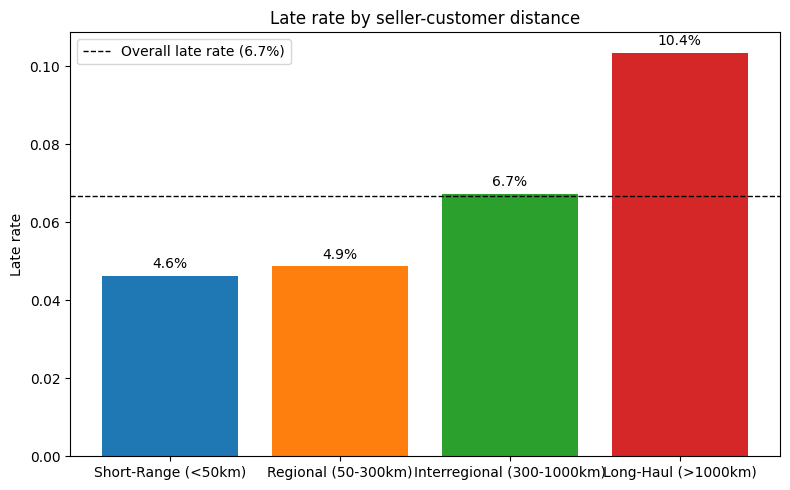

In [36]:
late_rate = ct_distance.loc['Late'] / ct_distance.sum()
overall_rate = ct_distance.loc['Late'].sum() / ct_distance.values.sum()
colors = sns.color_palette('tab10', n_colors=len(late_rate))

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(late_rate.index.astype(str), late_rate.values, color=colors)
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1,
           label=f'Overall late rate ({overall_rate:.1%})')
for i, v in enumerate(late_rate.values):
    ax.text(i, v + 0.002, f'{v:.1%}', ha='center')
ax.set_title('Late rate by seller-customer distance')
ax.set_ylabel('Late rate')
ax.legend()
plt.tight_layout()
plt.show()

We will perform a statistical hypothesis test (Chi-square Test of Independence) to test: is there a significant association between seller-customer distance group and an order being late.

Hypotheses:
- $H_0$: `is_late` is independent of the distance group.
- $H_1$: `is_late` is significantly associated with the distance group.


In [37]:
chi2, p_val, dof, z = chi_square_with_zscores(ct_distance)
z_crit = bonferroni_z_crit(k=ct_distance.shape[1])

print(f"Chi2-Statistic : {chi2:.4f}")
print(f"P-Value        : {p_val}")
print(f"Bonferroni z_crit (k={ct_distance.shape[1]}): {z_crit:.3f}")
print()
print(z.loc['Late'].round(2))

if p_val < 0.05:
    print("\nConclusion     : Reject H0! There IS a significant association between")
    print("                 delivery distance and an order being late.")
else:
    print("\nConclusion     : Fail to reject H0. No significant association found.")


Chi2-Statistic : 576.4019
P-Value        : 1.315109870764208e-124
Bonferroni z_crit (k=4): 2.498

distance_group
Short-Range (<50km)          -10.04
Regional (50-300km)          -11.96
Interregional (300-1000km)     0.87
Long-Haul (>1000km)           21.06
Name: Late, dtype: float64

Conclusion     : Reject H0! There IS a significant association between
                 delivery distance and an order being late.


`Long-Haul` is strongly associated with lateness

#### 1.2.3.2 Interstate vs intrastate shipping vs `is_late`

A coarser, binary version of the distance question that lets us see whether if crossing a state line specifically matter, independent of the exact kilometer distance?

- Intrastate = same state

- Interstate = different state


In [38]:
biv_item_df['is_interstate'] = biv_item_df['seller_geo_state'] != biv_item_df.merge(
    order_analysis_df[['order_id','customer_geo_state']], on='order_id')['customer_geo_state']

ct_interstate = pd.crosstab(biv_item_df['is_interstate'], biv_item_df['is_late']).T
ct_interstate.index = ['On-Time','Late']
ct_interstate.columns = ['Intrastate','Interstate']
print(ct_interstate)


         Intrastate  Interstate
On-Time       37365       63968
Late           1761        5472


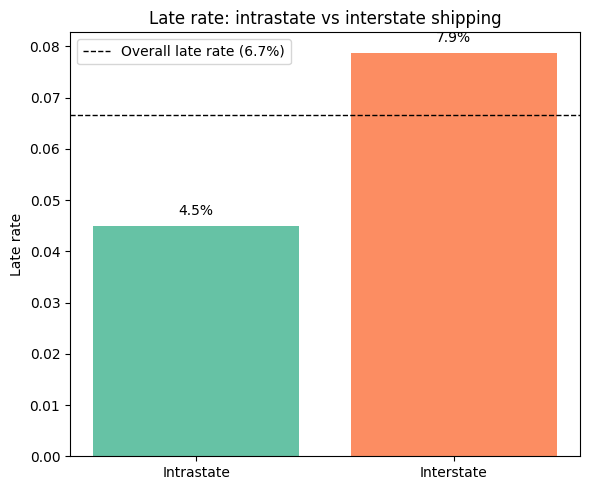

In [39]:
late_rate = ct_interstate.loc['Late'] / ct_interstate.sum()
overall_rate = ct_interstate.loc['Late'].sum() / ct_interstate.values.sum()
colors = sns.color_palette('Set2', n_colors=len(late_rate))

fig, ax = plt.subplots(figsize=(6,5))
ax.bar(late_rate.index.astype(str), late_rate.values, color=colors)
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1,
           label=f'Overall late rate ({overall_rate:.1%})')
for i, v in enumerate(late_rate.values):
    ax.text(i, v + 0.002, f'{v:.1%}', ha='center')
ax.set_title('Late rate: intrastate vs interstate shipping')
ax.set_ylabel('Late rate')
ax.legend()
plt.tight_layout()
plt.show()

We will perform a statistical hypothesis test (Chi-square Test of Independence) to test: is there a significant association between shipping across state lines and an order being late.

Hypotheses:
- $H_0$: `is_late` is independent of whether the shipment crosses a state line.
- $H_1$: `is_late` is significantly associated with whether the shipment crosses a state line.


In [40]:
chi2, p_val, dof, expected = stats.chi2_contingency(ct_interstate)

print(f"Chi2-Statistic : {chi2:.4f}")
print(f"P-Value        : {p_val:.6f}")

if p_val < 0.05:
    print("\nConclusion     : Reject H0! There IS a significant association between")
    print("                 interstate shipping and an order being late.")
else:
    print("\nConclusion     : Fail to reject H0. No significant association found.")


Chi2-Statistic : 459.0394
P-Value        : 0.000000

Conclusion     : Reject H0! There IS a significant association between
                 interstate shipping and an order being late.


highly significant, consistent with the distance finding above. crossing a state line is itself a strong simple indicator for elevated risk even without knowing the exact distance.


#### 1.2.3.3 Seller-to-customer state route vs `is_late`

**Why check this:** distance and interstate status are both aggregate
summaries. This looks at specific state-to-state routes directly --
restricted to routes with at least 100 orders, so the comparison isn't
dominated by rare, noisy routes.


In [41]:
cust_state = order_analysis_df[['order_id','customer_geo_state']]
route_df = biv_item_df.merge(cust_state, on='order_id')
route_df['route'] = route_df['seller_geo_state'] + '_to_' + route_df['customer_geo_state']

major_routes = route_df['route'].value_counts()[lambda x: x >= 100]
sub = route_df[route_df['route'].isin(major_routes.index)]

print(f"Routes with >=100 orders: {len(major_routes)}, covering {len(sub):,} of {len(route_df):,} item-order rows")


Routes with >=100 orders: 75, covering 103,350 of 108,566 item-order rows


We will perform a statistical hypothesis test (Chi-square Test of Independence) to test: is there a significant association between the specific seller-to-customer state route and an order being late.

Hypotheses:
- $H_0$: `is_late` is independent of the specific route.
- $H_1$: `is_late` is significantly associated with the specific route.


In [42]:
ct_route = pd.crosstab(sub['route'], sub['is_late'])
chi2, p_val, dof, expected = stats.chi2_contingency(ct_route)

print(f"Chi2-Statistic : {chi2:.4f}")
print(f"P-Value        : {p_val}")
print(f"dof            : {dof}")

if p_val < 0.05:
    print("\nConclusion     : Reject H0! There IS a significant association between")
    print("                 specific route and an order being late.")
else:
    print("\nConclusion     : Fail to reject H0. No significant association found.")


Chi2-Statistic : 2400.1571
P-Value        : 0.0
dof            : 74

Conclusion     : Reject H0! There IS a significant association between
                 specific route and an order being late.


In [43]:
ct_route_T = ct_route.T
ct_route_T.index = ['On-Time','Late']
_, _, _, z_route = chi_square_with_zscores(ct_route_T)
z_crit = bonferroni_z_crit(k=len(major_routes))

z_sorted = z_route.loc['Late'].sort_values(ascending=False)
print(f"Bonferroni z_crit (k={len(major_routes)} routes): {z_crit:.3f}")
print()
print("Riskiest routes:")
print(z_sorted.head(5))
print()
print("Safest routes:")
print(z_sorted.tail(5))


Bonferroni z_crit (k=75 routes): 3.403

Riskiest routes:
route
SP_to_RJ    28.900209
SP_to_BA    12.885366
SP_to_MA    12.665634
SP_to_AL    10.741215
SP_to_CE     9.664262
Name: Late, dtype: float64

Safest routes:
route
RS_to_SP    -6.034626
MG_to_MG    -7.073318
MG_to_SP    -7.140568
PR_to_SP    -8.304326
SP_to_SP   -18.164242
Name: Late, dtype: float64


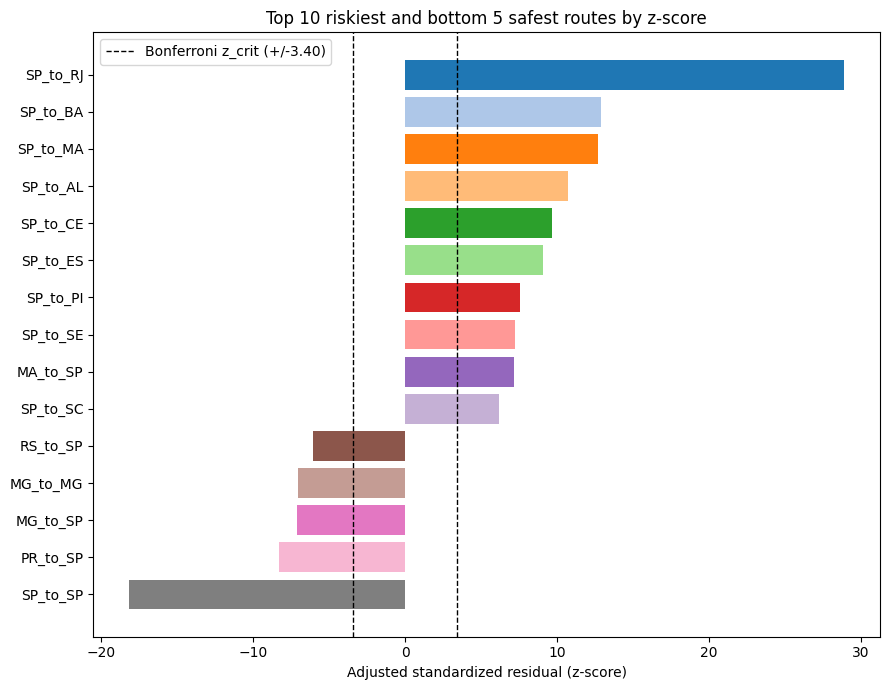

In [44]:
top_n = 10
plot_data = pd.concat([z_sorted.head(top_n), z_sorted.tail(5)])
colors = sns.color_palette('tab20', n_colors=len(plot_data))

fig, ax = plt.subplots(figsize=(9,7))
ax.barh(plot_data.index[::-1], plot_data.values[::-1], color=colors[::-1])
ax.axvline(z_crit, color='black', linestyle='--', linewidth=1, label=f'Bonferroni z_crit (+/-{z_crit:.2f})')
ax.axvline(-z_crit, color='black', linestyle='--', linewidth=1)
ax.set_title(f'Top {top_n} riskiest and bottom 5 safest routes by z-score')
ax.set_xlabel('Adjusted standardized residual (z-score)')
ax.legend()
plt.tight_layout()
plt.show()

significant overall. The single riskiest route by z-score is worth checking directly rather than trusting the ranking alone. a route's z-score reflects both its actual rate *and* its volume, so a high-volume route with only a modestly elevated rate can outrank a lower-volume route with a more extreme rate. Beyond the top entry, the pattern matches the broader distance/interstate findings: routes into Brazil's more remote regions dominate the risky end, while short, high-volume corridors near the São Paulo hub dominate the safe end.


### **1.2.4 Product Factors**

#### 1.2.4.1 Product-level late exposure

a look at how widespread late-delivery exposure is across the product catalog. what share of distinct products have appeared in at least one late order. This is a different question from "what fraction of orders in a category are late" (next), since a product sold many times could show up here even if only one of its many sales happened to be late.


In [45]:
prod_join = df[['order_id','order_item_id','product_id']]
biv_item_df_with_pid = biv_item_df.merge(prod_join, on=['order_id'], how='left')

total_late_products = biv_item_df_with_pid.loc[biv_item_df_with_pid['is_late'], 'product_id'].nunique()
total_products = biv_item_df_with_pid['product_id'].nunique()

print(f"Distinct products that appeared in at least one late order: {total_late_products:,} of {total_products:,} ({total_late_products/total_products:.1%})")

Distinct products that appeared in at least one late order: 4,413 of 31,875 (13.8%)


13-14% of the products ever sold on the platform have been involved in at least one late delivery. 


#### 1.2.4.2 Late delivery rate by product category (order/item-level)

the standard version of "does category matter" what fraction of *orders* (not products) in each category actually arrive late. Restricted to categories with at least the median item-count across categories, so the comparison isn't dominated by categories with only a handful of sales.


In [46]:
cat_summary = biv_item_df.groupby('product_category_name_english').agg(
    n_items=('order_id','size'),
    late_rate=('is_late','mean')
)
median_n = cat_summary['n_items'].median()
cat_summary_filtered = cat_summary[cat_summary['n_items'] >= median_n].sort_values('late_rate', ascending=False)

print(f"Categories included (n_items >= median of {median_n:.0f}): {len(cat_summary_filtered)}")
print()
print(cat_summary_filtered.head(10))


Categories included (n_items >= median of 267): 37

                               n_items  late_rate
product_category_name_english                    
audio                              358   0.117318
home_comfort                       452   0.097345
office_furniture                  1659   0.080169
baby                              2942   0.077498
electronics                       2698   0.076723
health_beauty                     9294   0.076393
musical_instruments                644   0.074534
construction_tools_lights          297   0.074074
watches_gifts                     5754   0.072819
food                               490   0.071429


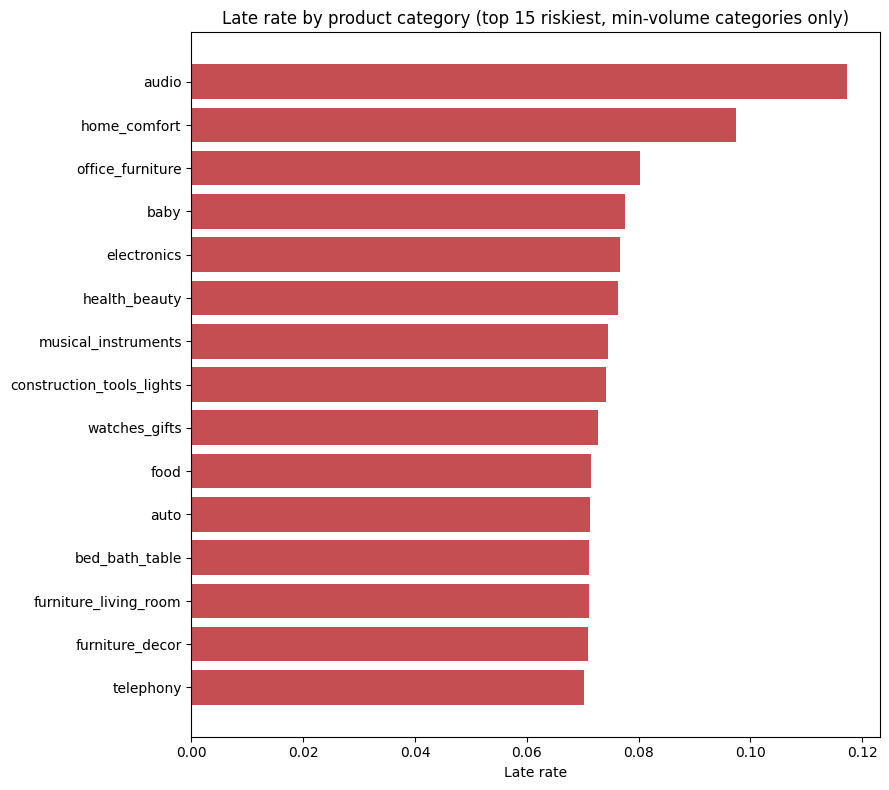

In [47]:
fig, ax = plt.subplots(figsize=(9,8))
top15 = cat_summary_filtered.head(15).sort_values('late_rate')
ax.barh(top15.index, top15['late_rate'], color='#C44E52')
ax.set_title('Late rate by product category (top 15 riskiest, min-volume categories only)')
ax.set_xlabel('Late rate')
plt.tight_layout()
plt.show()


We will perform a statistical hypothesis test (Chi-square Test of Independence) to test: is there a significant association between product category and an order being late.

Hypotheses:
- $H_0$: `is_late` is independent of product category.
- $H_1$: `is_late` is significantly associated with product category.


In [48]:
sub = biv_item_df[biv_item_df['product_category_name_english'].isin(cat_summary_filtered.index)]
ct_cat = pd.crosstab(sub['product_category_name_english'], sub['is_late'])
chi2, p_val, dof, expected = stats.chi2_contingency(ct_cat)

print(f"Chi2-Statistic : {chi2:.4f}")
print(f"P-Value        : {p_val}")
print(f"dof            : {dof}")

if p_val < 0.05:
    print("\nConclusion     : Reject H0! There IS a significant association between")
    print("                 product category and an order being late.")
else:
    print("\nConclusion     : Fail to reject H0. No significant association found.")


Chi2-Statistic : 146.2113
P-Value        : 3.1581226794514597e-15
dof            : 36

Conclusion     : Reject H0! There IS a significant association between
                 product category and an order being late.


significant overall. A handful of categories (audio, home comfort, office furniture) sit meaningfully above the baseline late rate. Worth noting this is a real but comparatively modest effect next to the geographic findings above. category shifts the rate by a few percentage points, while distance/interstate shift it much more.


#### 1.2.4.3 Delay length across categories, among late orders

the previous test asked whether a category makes lateness *more likely*. This asks a different question -- among orders that are already late, does the category relate to *how late* they tend to be. Restricted to categories with at least 30 late orders, so each group has a reasonably stable median.


In [49]:
late_item_df = biv_item_df_with_pid[biv_item_df_with_pid['is_late']].merge(
    df[['order_id','order_delivered_customer_date','order_estimated_delivery_date']].drop_duplicates('order_id'),
    on='order_id'
)
late_item_df['delay_days'] = (late_item_df['order_delivered_customer_date'].dt.normalize() -
                                late_item_df['order_estimated_delivery_date'].dt.normalize()).dt.days

cat_delay = late_item_df.groupby('product_category_name_english')['delay_days'].agg(['median','count'])
cat_delay = cat_delay[cat_delay['count'] >= 30].sort_values('median', ascending=False)

print(cat_delay.head(10))


                                 median  count
product_category_name_english                 
construction_tools_construction    11.0     67
home_comfort                       10.0     54
furniture_living_room              10.0     45
garden_tools                        9.0    475
fashion_bags_accessories            7.0    114
toys                                7.0    282
telephony                           7.0    361
stationery                          7.0    213
sports_leisure                      7.0    617
perfumery                           7.0    268


We will perform a statistical hypothesis test (Kruskal-Wallis H-test) to test: does delay length (in days) differ significantly across product categories, among late orders. A non-parametric test is used here rather than ANOVA since `delay_days` is heavily skewed (established earlier in this project) and there are more than two groups being compared, ruling out a two-sample t-test.

Hypotheses:
- $H_0$: The distribution of `delay_days` is the same across all product categories.
- $H_1$: At least one product category's `delay_days` distribution differs from the others.


In [50]:
groups = [g['delay_days'].values for _, g in late_item_df.groupby('product_category_name_english') if len(g) >= 30]

h_stat, p_val = stats.kruskal(*groups)

print(f"H-Statistic : {h_stat:.4f}")
print(f"P-Value     : {p_val}")
print(f"Groups      : {len(groups)} categories with >=30 late orders each")

if p_val < 0.05:
    print("\nConclusion  : Reject H0! Delay length DOES differ significantly across")
    print("              product categories among late orders.")
else:
    print("\nConclusion  : Fail to reject H0. No significant difference in delay length")
    print("              across categories.")


H-Statistic : 278.2110
P-Value     : 4.677894535518525e-41
Groups      : 33 categories with >=30 late orders each

Conclusion  : Reject H0! Delay length DOES differ significantly across
              product categories among late orders.


significant, though the effect is modes. medians across the top categories cluster tightly, a much narrower spread than the categorical late-rate differences above. Consistent with the broader project finding that crossing into "late" matters more than the exact degree of lateness.


#### 1.2.4.4 Product physical characteristics vs `is_late`

**Why check this:** heavier or bulkier items could plausibly take longer
to handle and ship. Distributions for weight and dimensions are heavily
skewed (established in the univariate pass), so a non-parametric test
(Mann-Whitney U) is used instead of a t-test, comparing medians rather
than means.


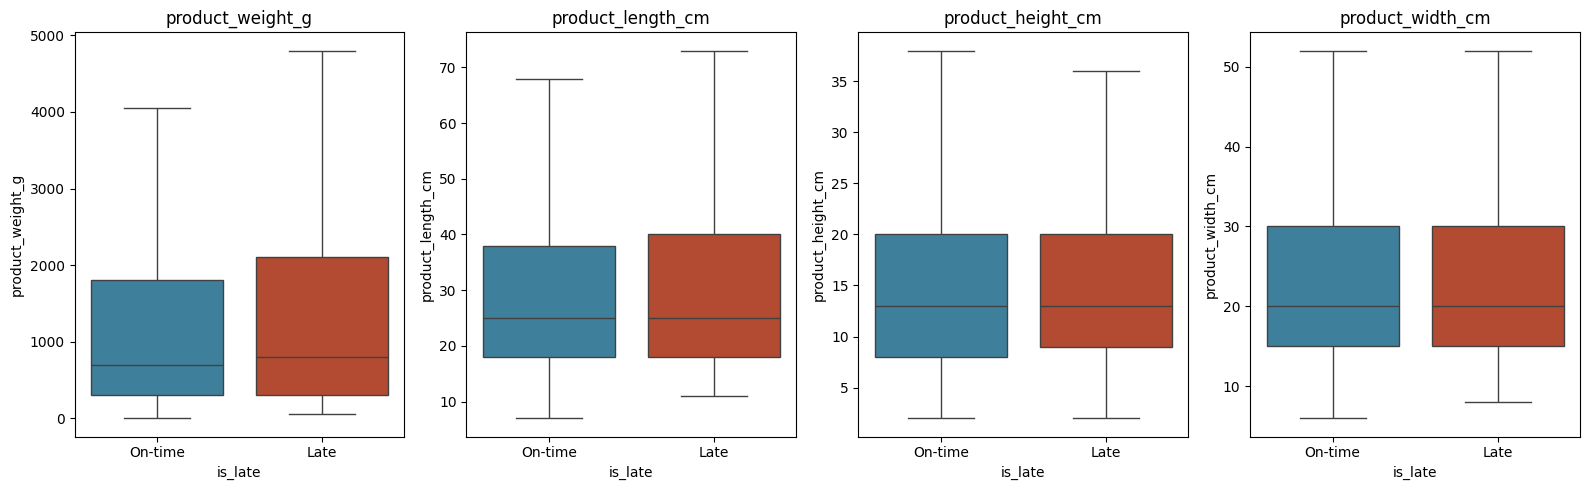

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(16,5))
for ax, col in zip(axes, ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']):
    sns.boxplot(data=biv_item_df, x='is_late', y=col, ax=ax,
                hue='is_late', palette=['#2E86AB','#C73E1D'], showfliers=False, legend=False)
    ax.set_xticks([0,1]); ax.set_xticklabels(['On-time','Late'])
    ax.set_title(col)
plt.tight_layout()
plt.show()


We will perform a statistical hypothesis test (Mann-Whitney U Test) to test: does the late-delivery group have significantly different product weight/dimensions compared to the on-time group.

Hypotheses:
- $H_0$: There is no significant difference in the product characteristic's distribution between late and on-time deliveries.
- $H_1$: There is a significant difference in the product characteristic's distribution between late and on-time deliveries.


In [52]:
for col in ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']:
    late_vals = biv_item_df.loc[biv_item_df['is_late']==True, col].dropna()
    on_time_vals = biv_item_df.loc[biv_item_df['is_late']==False, col].dropna()

    u_stat, p_value = stats.mannwhitneyu(late_vals, on_time_vals, alternative='two-sided')

    print(f"--- {col} ---")
    print(f"Late median: {late_vals.median():.1f}  |  On-time median: {on_time_vals.median():.1f}")
    print(f"U-Statistic : {u_stat:.0f}")
    print(f"P-Value     : {p_value}")
    if p_value < 0.05:
        print("Conclusion  : Reject H0! Significant difference found.")
    else:
        print("Conclusion  : Fail to reject H0. No significant difference found.")
    print()


--- product_weight_g ---
Late median: 800.0  |  On-time median: 700.0
U-Statistic : 383067045
P-Value     : 9.593481744223629e-11
Conclusion  : Reject H0! Significant difference found.

--- product_length_cm ---
Late median: 25.0  |  On-time median: 25.0
U-Statistic : 377094426
P-Value     : 3.1404131407694594e-05
Conclusion  : Reject H0! Significant difference found.

--- product_height_cm ---
Late median: 13.0  |  On-time median: 13.0
U-Statistic : 375374380
P-Value     : 0.0004884127324796257
Conclusion  : Reject H0! Significant difference found.

--- product_width_cm ---
Late median: 20.0  |  On-time median: 20.0
U-Statistic : 366462538
P-Value     : 0.9823528010768923
Conclusion  : Fail to reject H0. No significant difference found.



`product_weight_g` shows the clearest difference where heavier orders matters. Length and height are statistically significant too, but the gap between medians is small. with a sample this large, even a tiny distributional difference clears the p < 0.05 bar, so these two are much weaker findings in practice than the p-value alone suggests and width shows no meaningful difference at all